In [265]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

In [266]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "02_model_training"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Data Collection

In [267]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [268]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-10-01 03:45:00,63737.19,63744.00,63674.00,63723.48,138.21229
1,2024-10-01 04:00:00,63723.47,63840.00,63652.06,63672.01,248.39471
2,2024-10-01 04:15:00,63672.01,63788.00,63672.00,63785.99,114.03599
3,2024-10-01 04:30:00,63785.99,63866.66,63769.06,63807.99,151.24235
4,2024-10-01 04:45:00,63808.00,63879.81,63774.10,63868.94,265.07981


# Technical Indicators

### Momentum

In [269]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()


In [270]:
##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

In [271]:
## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

In [272]:
## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

In [273]:
## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

In [274]:
## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

In [275]:
## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

In [276]:
## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

In [277]:
## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [278]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

In [279]:
## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

In [280]:
##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

In [281]:
##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

In [282]:
##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

In [283]:
##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

In [284]:
##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

In [285]:
##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

In [286]:
## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [287]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

In [288]:
## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

In [289]:
## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

In [290]:
## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

In [291]:
## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [292]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

In [293]:
## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

In [294]:
## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

In [295]:
## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

In [296]:
## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

In [297]:
## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

In [298]:
## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

In [299]:
## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

In [300]:
## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

In [301]:
## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

In [302]:
## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

In [303]:
df.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-10-01 03:45:00,63737.19,63744.00,63674.00,63723.48,138.21229,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-10-01 04:00:00,63723.47,63840.00,63652.06,63672.01,248.39471,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-10-01 04:15:00,63672.01,63788.00,63672.00,63785.99,114.03599,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-10-01 04:30:00,63785.99,63866.66,63769.06,63807.99,151.24235,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-10-01 04:45:00,63808.00,63879.81,63774.10,63868.94,265.07981,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Constants

In [304]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Explore Data

### Correlation

In [305]:
# OCHLV with MOMENTUM
df[OCHLV + MOMENTUM].corr()

,open,close,high,low,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
open,1.000000,0.999883,0.999931,0.999922,-0.157683,0.018608,0.999748,0.013053,-0.001660,0.014418,0.006905,0.000315,0.007980,0.002722,0.003406,-0.011347,-0.002751,0.001390,0.010788
close,0.999883,1.000000,0.999936,0.999931,-0.157588,0.019013,0.999672,0.014040,0.001153,0.014567,0.006856,0.000315,0.007923,0.007021,0.008620,-0.004680,0.003356,0.003475,0.011826
high,0.999931,0.999936,1.000000,0.999870,-0.151484,0.018395,0.999713,0.013074,-0.000450,0.014054,0.010153,0.002796,0.010415,0.004583,0.005776,-0.007879,-0.000003,0.002171,0.010968
low,0.999922,0.999931,0.999870,1.000000,-0.164335,0.019650,0.999667,0.014354,0.000444,0.015128,0.003441,-0.002360,0.005402,0.005792,0.006924,-0.007659,0.000712,0.002967,0.012035
volume,-0.157683,-0.157588,-0.151484,-0.164335,1.000000,-0.009214,-0.156443,0.002527,-0.029807,0.012219,0.493687,0.413115,0.348685,-0.013966,-0.011625,-0.012873,-0.018032,-0.017657,0.000348
AO,0.018608,0.019013,0.018395,0.019650,-0.009214,1.000000,0.004827,0.963122,0.451712,0.878382,-0.053041,-0.002209,-0.061964,0.733226,0.747055,0.044669,0.426822,0.532104,0.868912
KAMA,0.999748,0.999672,0.999713,0.999667,-0.156443,0.004827,1.000000,-0.000174,-0.015768,0.004875,0.008663,0.000991,0.009686,-0.012077,-0.011246,-0.019208,-0.015347,-0.013892,-0.001804
PPO,0.013053,0.014040,0.013074,0.014354,0.002527,0.963122,-0.000174,1.000000,0.338837,0.953650,-0.042649,0.005157,-0.053859,0.700733,0.751871,0.013321,0.399516,0.483188,0.884414
PPO_HIST,-0.001660,0.001153,-0.000450,0.000444,-0.029807,0.451712,-0.015768,0.338837,1.000000,0.040013,-0.055385,-0.042909,-0.041115,0.826668,0.562353,0.588645,0.638000,0.685761,0.309448
PPO_SIGNAL,0.014418,0.014567,0.014054,0.015128,0.012219,0.878382,0.004875,0.953650,0.040013,1.000000,-0.027586,0.019201,-0.044049,0.479806,0.618664,-0.174125,0.220281,0.293874,0.840293


In [306]:
# OCHLV with VOLUME
df[OCHLV + VOLUME].corr()

,open,close,high,low,volume,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
open,1.000000,0.999883,0.999931,0.999922,-0.157683,0.619425,0.029072,-0.005516,0.011075,0.008287,0.004280,0.747316,0.373525,0.735985,0.999717
close,0.999883,1.000000,0.999936,0.999931,-0.157588,0.619332,0.031635,0.004036,0.013364,0.012807,0.006407,0.747336,0.373532,0.736033,0.999635
high,0.999931,0.999936,1.000000,0.999870,-0.151484,0.620740,0.029926,0.000293,0.012031,0.010592,0.005242,0.746408,0.375167,0.737165,0.999676
low,0.999922,0.999931,0.999870,1.000000,-0.164335,0.618080,0.030172,0.001021,0.013482,0.011456,0.006207,0.748444,0.371685,0.734672,0.999644
volume,-0.157683,-0.157588,-0.151484,-0.164335,1.000000,-0.035403,0.026717,-0.030313,-0.055536,0.060965,-0.015488,-0.246208,0.107674,0.018990,-0.157278
ADI,0.619425,0.619332,0.620740,0.618080,-0.035403,1.000000,-0.046481,-0.000283,-0.001056,-0.028846,-0.022097,0.328579,0.652080,0.714750,0.618773
CMF,0.029072,0.031635,0.029926,0.030172,0.026717,-0.046481,1.000000,0.135113,0.421600,0.265130,0.555323,-0.035232,0.033804,0.042333,0.019788
EoM,-0.005516,0.004036,0.000293,0.001021,-0.030313,-0.000283,0.135113,1.000000,0.242509,0.205557,0.133887,0.002773,-0.002284,-0.001380,-0.007979
EMV,0.011075,0.013364,0.012031,0.013482,-0.055536,-0.001056,0.421600,0.242509,1.000000,0.403342,0.686682,0.006227,-0.005340,0.000214,-0.006142
FI,0.008287,0.012807,0.010592,0.011456,0.060965,-0.028846,0.265130,0.205557,0.403342,1.000000,0.316607,-0.011739,0.007009,0.029983,-0.001848


In [307]:
# OCHLV with VOLATILITY
df[OCHLV + VOLATILITY].corr()

,open,close,high,low,volume,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
open,1.000000,0.999883,0.999931,0.999922,-0.157683,-0.019812,0.998858,-0.001830,0.998779,-0.005872,...,-0.002038,-0.205985,0.999311,0.006087,0.999338,0.010364,0.999384,0.004128,-0.257131,-0.155528
close,0.999883,1.000000,0.999936,0.999931,-0.157588,-0.019738,0.998762,0.002722,0.998677,-0.010584,...,0.003390,-0.205800,0.999208,0.009604,0.999235,0.006621,0.999281,0.009607,-0.257034,-0.155941
high,0.999931,0.999936,1.000000,0.999870,-0.151484,-0.014471,0.998959,0.002048,0.998592,-0.006844,...,0.000331,-0.201193,0.999320,0.008367,0.999239,0.009458,0.999339,0.006751,-0.252367,-0.152577
low,0.999922,0.999931,0.999870,1.000000,-0.164335,-0.025328,0.998614,-0.000743,0.998825,-0.010080,...,0.001206,-0.210770,0.999153,0.007717,0.999294,0.007075,0.999283,0.007610,-0.261960,-0.159122
volume,-0.157683,-0.157588,-0.151484,-0.164335,1.000000,0.539078,-0.140215,0.209003,-0.173829,0.202659,...,-0.021338,0.582562,-0.151350,0.095650,-0.162177,0.143603,-0.157170,-0.003927,0.518831,0.331669
ATR,-0.019812,-0.019738,-0.014471,-0.025328,0.539078,1.000000,0.006413,0.004721,-0.047203,0.014955,...,0.000717,0.855747,-0.007568,0.000624,-0.029283,0.047375,-0.020443,-0.021880,0.943312,0.659032
BBANDS_HIGH,0.998858,0.998762,0.998959,0.998614,-0.140215,0.006413,1.000000,-0.010377,0.997631,0.002523,...,-0.024079,-0.174784,0.999646,-0.008194,0.999038,0.033785,0.999404,-0.021188,-0.229946,-0.117486
BBANDS_HIGH_INDI,-0.001830,0.002722,0.002048,-0.000743,0.209003,0.004721,-0.010377,1.000000,-0.010665,-0.062590,...,0.343311,0.027319,-0.010650,0.409646,-0.010232,-0.141340,-0.010761,0.427908,-0.013855,-0.118848
BBANDS_LOWER,0.998779,0.998677,0.998592,0.998825,-0.173829,-0.047203,0.997631,-0.010665,1.000000,0.002376,...,-0.025096,-0.237566,0.999046,-0.017981,0.999652,0.024188,0.999410,-0.022940,-0.282191,-0.159716
BBANDS_LOWER_INDI,-0.005872,-0.010584,-0.006844,-0.010080,0.202659,0.014955,0.002523,-0.062590,0.002376,1.000000,...,-0.378826,0.020701,0.002898,-0.152181,0.003079,0.441988,0.002687,-0.430415,-0.009162,0.059565


In [308]:
# OCHLV with TREND
df[OCHLV + TREND].corr()

,open,close,high,low,volume,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
open,1.000000,0.999883,0.999931,0.999922,-0.157683,-0.022988,0.037293,0.041675,0.003314,0.005121,...,-0.026328,0.021847,0.023730,-0.001572,-0.005530,0.999626,0.005092,-0.004246,0.004745,0.999809
close,0.999883,1.000000,0.999936,0.999931,-0.157588,-0.023014,0.040301,0.038566,0.004123,0.004317,...,-0.025490,0.022839,0.023874,0.001267,-0.005563,0.999530,0.007022,-0.006212,0.006722,0.999727
high,0.999931,0.999936,1.000000,0.999870,-0.151484,-0.021138,0.039324,0.040639,0.004568,0.005622,...,-0.026176,0.021862,0.023359,-0.000363,-0.002992,0.999580,0.005400,-0.005903,0.005735,0.999765
low,0.999922,0.999931,0.999870,1.000000,-0.164335,-0.024885,0.039530,0.038173,0.003284,0.003284,...,-0.025464,0.023168,0.024453,0.000552,-0.008208,0.999535,0.007699,-0.005440,0.006681,0.999733
volume,-0.157683,-0.157588,-0.151484,-0.164335,1.000000,0.245750,0.053722,0.100511,0.113159,0.110775,...,-0.010649,-0.004711,0.005111,-0.031556,0.285031,-0.157098,-0.077593,-0.054739,-0.012265,-0.157341
ADX,-0.022988,-0.023014,-0.021138,-0.024885,0.245750,1.000000,0.020538,0.036276,-0.004463,0.025433,...,-0.013550,-0.031416,-0.030489,-0.008999,0.371994,-0.024511,-0.007668,-0.009115,0.000650,-0.024721
ADX_POS,0.037293,0.040301,0.039324,0.039530,0.053722,0.020538,1.000000,-0.728027,0.583277,-0.521935,...,0.362990,0.716721,0.611003,0.469097,-0.009031,0.017519,0.734718,-0.775729,0.766538,0.023688
ADX_NEG,0.041675,0.038566,0.040639,0.038173,0.100511,0.036276,-0.728027,1.000000,-0.513510,0.580013,...,-0.376888,-0.693888,-0.579989,-0.490198,0.114076,0.056984,-0.761284,0.735199,-0.759786,0.050806
AROON_UP,0.003314,0.004123,0.004568,0.003284,0.113159,-0.004463,0.583277,-0.513510,1.000000,-0.458664,...,0.269862,0.555828,0.518259,0.225228,0.043560,-0.005962,0.496504,-0.555950,0.533956,-0.002159
AROON_DOWN,0.005121,0.004317,0.005622,0.003284,0.110775,0.025433,-0.521935,0.580013,-0.458664,1.000000,...,-0.285751,-0.570331,-0.528790,-0.240742,0.221200,0.014861,-0.555601,0.511351,-0.541836,0.010873


In [309]:
dataset = df.copy()

# Data Cleaning

In [310]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35040 non-null  datetime64[ns]
 1   open                 35040 non-null  float64       
 2   high                 35040 non-null  float64       
 3   low                  35040 non-null  float64       
 4   close                35040 non-null  float64       
 5   volume               35040 non-null  float64       
 6   AO                   35007 non-null  float64       
 7   KAMA                 35031 non-null  float64       
 8   PPO                  35015 non-null  float64       
 9   PPO_HIST             35007 non-null  float64       
 10  PPO_SIGNAL           35007 non-null  float64       
 11  PVO                  35015 non-null  float64       
 12  PVO_HIST             35007 non-null  float64       
 13  PVO_SIGNAL           35007 non-

In [311]:
dataset = DataCleaning(dataset).clean_data()

In [312]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 40 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35000 non-null  datetime64[ns]
 1   open                 35000 non-null  float64       
 2   high                 35000 non-null  float64       
 3   low                  35000 non-null  float64       
 4   close                35000 non-null  float64       
 5   volume               35000 non-null  float64       
 6   AO                   35000 non-null  float64       
 7   KAMA                 35000 non-null  float64       
 8   PPO                  35000 non-null  float64       
 9   PPO_HIST             35000 non-null  float64       
 10  PPO_SIGNAL           35000 non-null  float64       
 11  PVO                  35000 non-null  float64       
 12  PVO_HIST             35000 non-null  float64       
 13  PVO_SIGNAL           35000 non-null

# Feature Engineering

### Timestamp Features

In [313]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

### Lag Features (Targets)

In [314]:
def create_targets(df, target_column='close', n_steps=16):
    
    for step in range(1, n_steps + 1):
        df[f'close_step_{step}'] = df[target_column].shift(-step)
    
    return df


In [315]:
targets = create_targets(dataset, target_column='close', n_steps=16)

In [316]:
targets.tail(20)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
35020,2025-09-30 22:45:00,113923.60,114022.91,113917.14,113940.39,54.77512,407.977647,114225.182822,0.147064,-0.055418,...,113969.19,114239.53,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15
35021,2025-09-30 23:00:00,113940.40,113940.80,113765.42,113839.99,84.05759,307.088559,114194.764430,0.119377,-0.066484,...,114239.53,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00
35022,2025-09-30 23:15:00,113839.99,114022.88,113769.58,113966.17,102.08752,224.132853,114153.782060,0.105151,-0.064568,...,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16
35023,2025-09-30 23:30:00,113966.17,113983.98,113851.16,113971.49,47.31461,177.042647,114131.374821,0.093179,-0.061232,...,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16,114351.59
35024,2025-09-30 23:45:00,113971.50,114048.94,113945.86,114048.93,34.97788,158.388618,114126.799163,0.088157,-0.053003,...,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16,114351.59,NaN
35025,2025-10-01 00:00:00,114048.94,114308.00,114048.93,114156.18,117.94697,169.031176,114128.124284,0.090719,-0.040353,...,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16,114351.59,NaN,NaN
35026,2025-10-01 00:15:00,114156.17,114177.93,113966.67,114021.86,120.20758,184.225941,114125.104367,0.082296,-0.039021,...,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16,114351.59,NaN,NaN,NaN
35027,2025-10-01 00:30:00,114021.85,114231.26,113969.18,113969.19,99.36776,195.284529,114119.950312,0.071074,-0.040195,...,114427.88,114324.66,114272.15,114434.00,114471.16,114351.59,NaN,NaN,NaN,NaN
35028,2025-10-01 00:45:00,113969.19,114255.00,113969.18,114239.53,97.06785,206.024853,114125.569754,0.080382,-0.024708,...,114324.66,114272.15,114434.00,114471.16,114351.59,NaN,NaN,NaN,NaN,NaN
35029,2025-10-01 01:00:00,114239.53,114398.97,114142.99,114348.16,149.14275,221.765559,114148.411095,0.094350,-0.008592,...,114272.15,114434.00,114471.16,114351.59,NaN,NaN,NaN,NaN,NaN,NaN


In [317]:
dataset = DataCleaning(targets).clean_data()

In [318]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
35019,2025-09-30 22:30:00,113996.00,114034.37,113883.01,113923.59,63.88545,512.130059,114248.445773,0.171301,-0.045035,...,114021.86,113969.19,114239.53,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66
35020,2025-09-30 22:45:00,113923.60,114022.91,113917.14,113940.39,54.77512,407.977647,114225.182822,0.147064,-0.055418,...,113969.19,114239.53,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15
35021,2025-09-30 23:00:00,113940.40,113940.80,113765.42,113839.99,84.05759,307.088559,114194.764430,0.119377,-0.066484,...,114239.53,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00
35022,2025-09-30 23:15:00,113839.99,114022.88,113769.58,113966.17,102.08752,224.132853,114153.782060,0.105151,-0.064568,...,114348.16,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16
35023,2025-09-30 23:30:00,113966.17,113983.98,113851.16,113971.49,47.31461,177.042647,114131.374821,0.093179,-0.061232,...,114367.72,114413.36,114549.99,114481.09,114427.88,114324.66,114272.15,114434.00,114471.16,114351.59


# Feature Selection

In [319]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

### Splitting X, y

In [320]:
dataset = dataset.sort_values('timestamp')

In [321]:
DROP_COLUMNS = ['timestamp', 'close_step_1', 'close_step_2', 'close_step_3', 'close_step_4', 'close_step_5', 'close_step_6', 'close_step_7', 'close_step_8', 'close_step_9', 'close_step_10', 'close_step_11', 'close_step_12', 'close_step_13', 'close_step_14', 'close_step_15', 'close_step_16']

In [322]:
def X_y_split(df, target='', drop_columns=[]):
    X = dataset.drop(columns=drop_columns)
    y = dataset[target]
    return X, y

### Feature Importance

In [323]:
xgb_close = XGBRegressor(eval_metric="rmse", early_stopping_rounds=100)

In [324]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [325]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum

##### Training to predict close_step_1

In [326]:
X, y = X_y_split(dataset, target='close_step_1', drop_columns=DROP_COLUMNS)

In [327]:
fold_metrics, oof_pred, gain_accum = model_training(X, y, xgb_close, tscv)

##### Error metrics by fold (100 folds)

In [328]:
valid_mask = ~np.isnan(oof_pred)
rmse_cv = root_mean_squared_error(y[valid_mask], oof_pred[valid_mask])
mae_cv  = mean_absolute_error(y[valid_mask], oof_pred[valid_mask])

In [329]:
metrics_df = pd.DataFrame(fold_metrics)

In [330]:
metrics_df.head()

,fold,rmse,mae
0,1,555.346908,379.531039
1,2,295.627216,190.243549
2,3,1965.634116,1469.687019
3,4,1046.893398,892.732967
4,5,267.182700,189.798067


##### Feature importance average

In [ ]:
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)

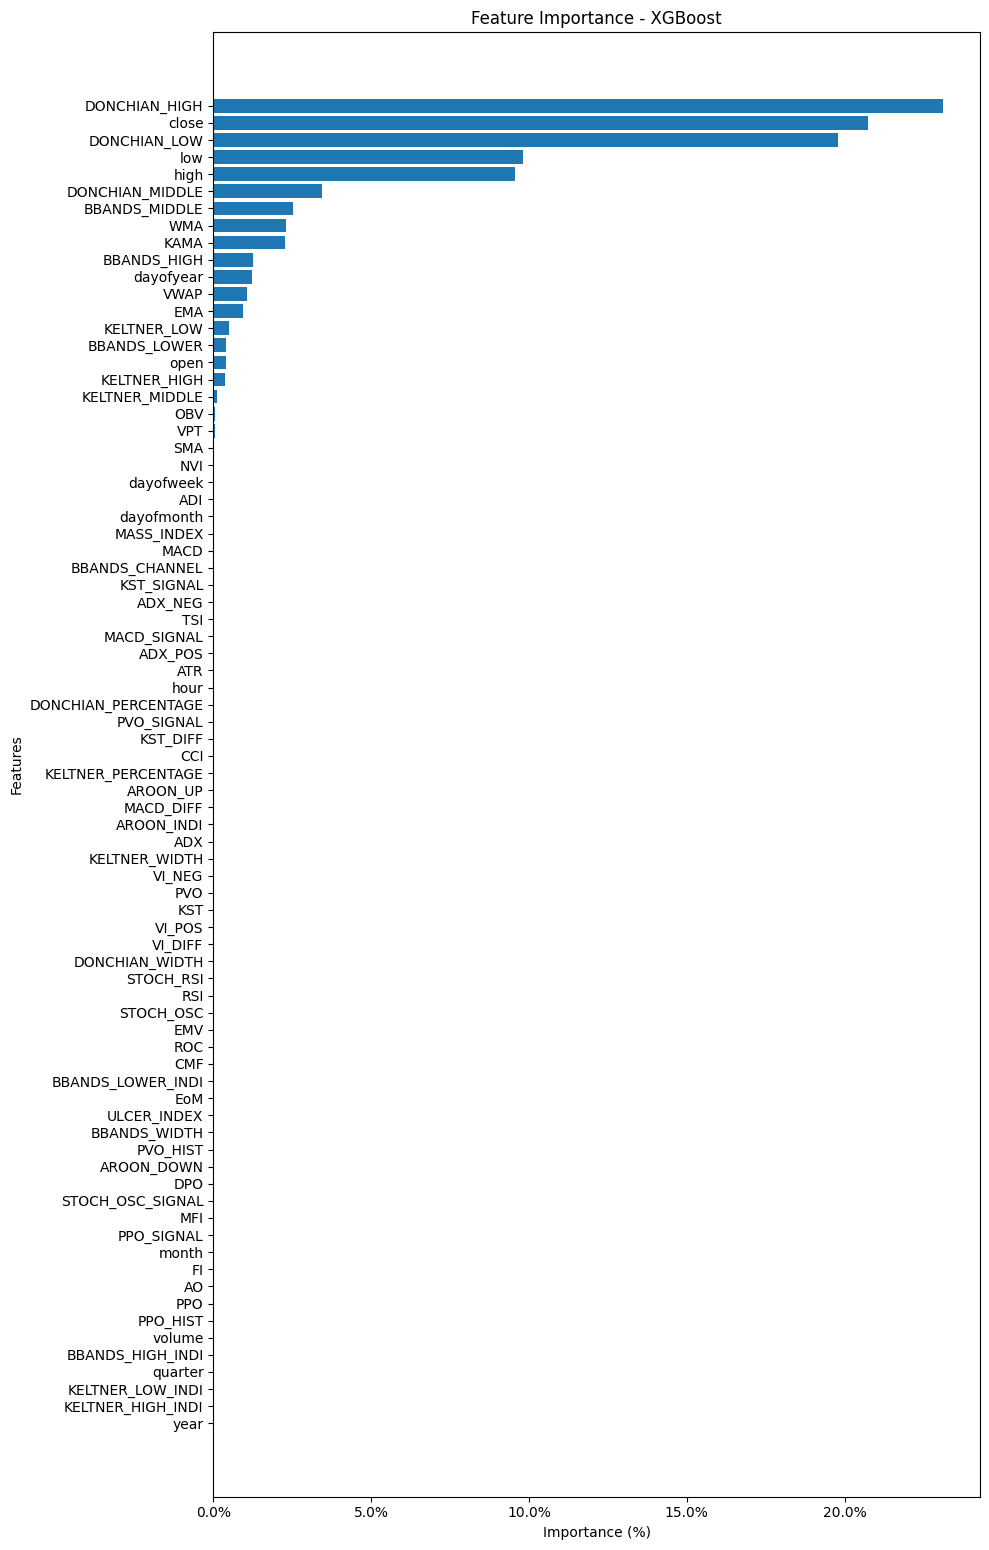

In [332]:
import matplotlib.ticker as ticker

importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100

plt.figure(figsize=(10, 0.2 * len(importance_df)))

plt.barh(importance_df["feature"], importance_df["gain_pct"])
plt.xlabel("Importance (%)")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost")

plt.gca().invert_yaxis()

# Show x-axis as percentage with 1 decimal
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()


In [333]:
importance_df.head(20)

,feature,avg_gain,gain_pct
0,DONCHIAN_HIGH,1.522799e+10,23.129139
1,close,1.365906e+10,20.746149
2,DONCHIAN_LOW,1.302307e+10,19.780176
3,low,6.449365e+09,9.795662
4,high,6.302186e+09,9.572117
5,DONCHIAN_MIDDLE,2.260404e+09,3.433230
6,BBANDS_MIDDLE,1.666799e+09,2.531629
7,WMA,1.512933e+09,2.297928
8,KAMA,1.504705e+09,2.285431
9,BBANDS_HIGH,8.287439e+08,1.258743


In [334]:
selected_features = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()
selected_features

['DONCHIAN_HIGH',
 'close',
 'DONCHIAN_LOW',
 'low',
 'high',
 'DONCHIAN_MIDDLE',
 'BBANDS_MIDDLE',
 'WMA',
 'KAMA',
 'BBANDS_HIGH',
 'dayofyear',
 'VWAP',
 'EMA']

### Hyperparameter tuning

In [335]:
cutoff_date = dataset['timestamp'].quantile(0.8)
close_train = dataset[dataset['timestamp'] < cutoff_date]
close_test = dataset[dataset['timestamp'] >= cutoff_date]

In [336]:
X_close_train = close_train[selected_features]
y_close_train = close_train['close_step_1']
X_close_test = close_test[selected_features]
y_close_test = close_test['close_step_1']

In [356]:
split_point = int(len(X_close_train) * 0.8)
X_train_split = X_close_train[:split_point]
y_train_split = y_close_train[:split_point]
X_val_split = X_close_train[split_point:]
y_val_split = y_close_train[split_point:]

In [357]:
params = {
    "n_estimators": [200, 500, 800, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10, 15],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.5, 1, 1.5, 2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0, 1, 5, 10],
    "reg_alpha": [0, 0.5, 1, 5]
}

In [358]:
tscv_hyperparameter_tuning = TimeSeriesSplit(n_splits=100)

In [359]:
xgb_hyperparameter_tuning = XGBRegressor(
    objective='reg:squarederror',
    early_stopping_rounds=50,
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
)

In [360]:
hyperparameter_tuning_close_step_1 = RandomizedSearchCV(
    xgb_hyperparameter_tuning, 
    param_distributions=params, 
    n_iter=10, 
    scoring='neg_root_mean_squared_error', 
    cv=tscv_hyperparameter_tuning, 
    verbose=3,
    n_jobs=1
)

In [361]:
hyperparameter_tuning_close_step_1.fit(
    X_train_split, 
    y_train_split,
    eval_set=[(X_val_split, y_val_split)],
    verbose=False
)

Fitting 100 folds for each of 10 candidates, totalling 1000 fits
[CV 1/100] END colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=0.5, reg_lambda=5, subsample=0.6;, score=-263.187 total time=   3.7s
[CV 2/100] END colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=0.5, reg_lambda=5, subsample=0.6;, score=-525.795 total time=   3.5s
[CV 3/100] END colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=0.5, reg_lambda=5, subsample=0.6;, score=-256.919 total time=   3.1s
[CV 4/100] END colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=0.5, reg_lambda=5, subsample=0.6;, score=-127.221 total time=   3.8s
[CV 5/100] END colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=5, min_child_weight=10, n_estimators=1000, reg_alpha=0.5, reg_lambd

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=100, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device='cuda',
                                          early_stopping_rounds=50,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None,
                                          feature_weights=None,...
                                          num_parallel_tree=None, ...),
                   n_jobs=1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.5, 1, 1.5, 2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 10, 15],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [200, 500, 800, 1000],
                                        'reg_alpha': [0, 0.5, 1, 5],
                                        'reg_lambda': [0, 1, 5, 10],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='neg_root_mean_squared_error', verbose=3)

In [364]:
print('\n Best hyperparameters:')
print(hyperparameter_tuning_close_step_1.best_params_)
results = pd.DataFrame(hyperparameter_tuning_close_step_1.cv_results_)
results


 Best hyperparameters:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1.5, 'colsample_bytree': 0.6}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_reg_lambda,param_reg_alpha,param_n_estimators,param_min_child_weight,param_max_depth,...,split93_test_score,split94_test_score,split95_test_score,split96_test_score,split97_test_score,split98_test_score,split99_test_score,mean_test_score,std_test_score,rank_test_score
0,3.929948,0.473708,0.013409,0.005376,0.6,5,0.5,1000,10,5,...,-222.800210,-204.545463,-236.433040,-191.239392,-150.484832,-241.920724,-2331.410076,-509.493231,775.316482,2
1,4.244105,1.458705,0.017580,0.007618,0.6,0,0.5,200,1,15,...,-259.408111,-293.362359,-278.703894,-231.987440,-197.136412,-303.276032,-2225.251303,-571.443697,768.864551,9
2,0.586015,0.098724,0.004731,0.007126,0.6,1,0.0,500,5,5,...,-229.306992,-211.426390,-239.293465,-188.539299,-150.454508,-256.589140,-2291.282506,-508.332105,756.781574,1
3,1.641922,0.279826,0.007923,0.007959,0.6,0,0.5,1000,10,10,...,-238.129244,-224.815123,-240.882739,-195.974586,-155.847491,-260.338468,-2416.045800,-519.690303,771.010159,5
4,2.846306,0.933331,0.009813,0.007424,0.8,1,5.0,1000,1,15,...,-237.330329,-234.583116,-258.614301,-200.489751,-178.383003,-295.148793,-2299.144247,-560.321653,775.567565,8
5,3.802842,0.378708,0.011967,0.006589,0.6,1,0.0,1000,5,7,...,-226.766984,-204.521638,-234.778293,-193.366516,-154.362040,-248.259740,-2346.016009,-516.547568,778.939369,4
6,5.608783,0.721420,0.023259,0.007618,0.6,1,0.0,800,1,10,...,-229.920089,-204.367289,-235.777069,-191.797743,-155.631602,-257.608521,-2367.178163,-544.166213,795.932025,6
7,2.108994,0.773457,0.008669,0.009213,0.8,5,5.0,500,1,15,...,-243.357529,-204.600785,-244.309744,-198.287957,-169.624871,-263.889750,-2315.859045,-546.054130,779.103133,7
8,0.751394,0.147447,0.004579,0.004826,0.6,1,0.5,1000,1,3,...,-228.787115,-208.236443,-240.822347,-195.760363,-148.919698,-244.451056,-2260.436121,-515.577948,767.606278,3
9,0.889314,0.037835,0.005345,0.006277,0.6,5,0.5,200,3,5,...,-1392.480848,-2031.377799,-2012.305334,-1971.750778,-1958.794911,-2180.296826,-4896.267090,-1816.836354,1493.166692,10


### Model Creation

In [365]:
best_params = hyperparameter_tuning_close_step_1.best_params_

In [366]:
xgb_open_close_step_1 = XGBRegressor(objective='reg:squarederror', **best_params)

In [367]:
xgb_open_close_step_1.fit(X_close_train, y_close_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1.5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [368]:
y_pred = xgb_open_close_step_1.predict(X_close_test)

### Validating the model

In [369]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [371]:
mse = mean_squared_error(y_close_test, y_pred)
rmse = root_mean_squared_error(y_close_test, y_pred)
mae = mean_absolute_error(y_close_test, y_pred)
r2 = r2_score(y_close_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Squared Error (MSE): 304007.46
Root Mean Squared Error (RMSE): 551.37
Mean Absolute Error (MAE): 373.26
R-squared (R2 Score): 0.97


### Comparing results

In [372]:
dataset_compare = close_test.copy()

In [373]:
dataset_compare["close_step_1_pred"] = y_pred

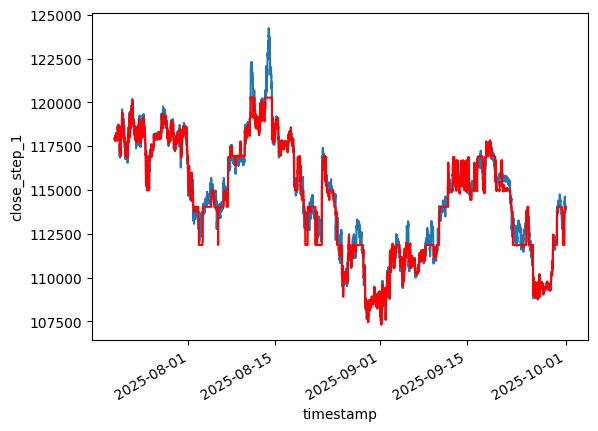

In [374]:
sns.lineplot(x="timestamp", y="close_step_1", data=dataset_compare)
sns.lineplot(x="timestamp", y="close_step_1_pred", data=dataset_compare, color="red")
plt.gcf().autofmt_xdate()
plt.show()

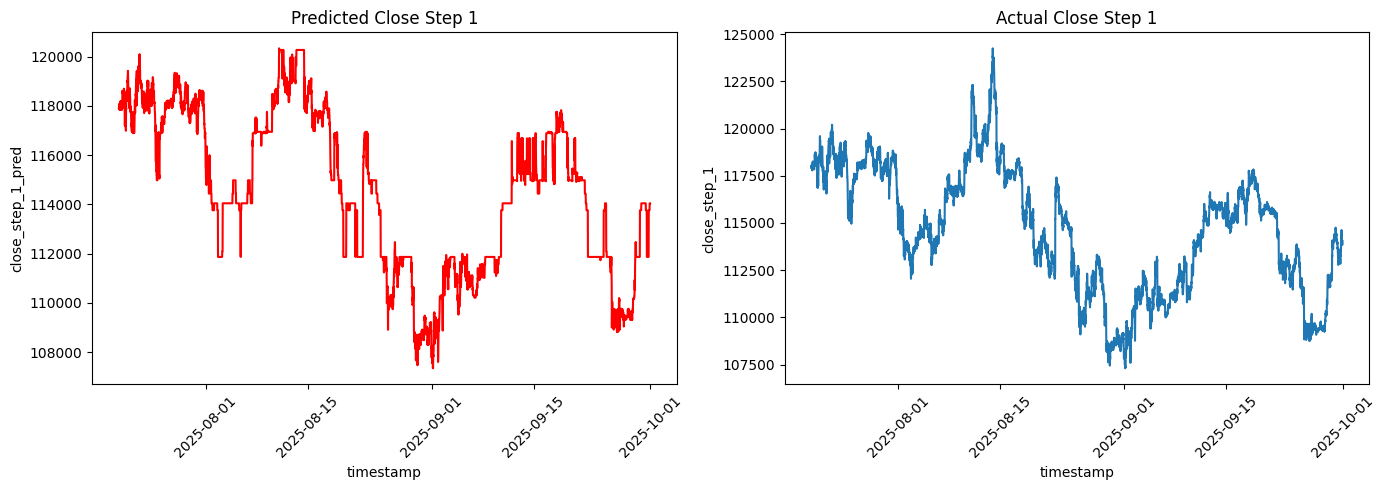

In [375]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# First plot (predicted)
sns.lineplot(x="timestamp", y="close_step_1_pred", 
             data=dataset_compare, color="red", ax=axes[0])
axes[0].set_title("Predicted Close Step 1")
axes[0].tick_params(axis='x', rotation=45)

# Second plot (actual)
sns.lineplot(x="timestamp", y="close_step_1", 
             data=dataset_compare, ax=axes[1])
axes[1].set_title("Actual Close Step 1")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [378]:
import joblib
import pickle
import json
import os
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"{model_folder}/xgb_model_{timestamp}.joblib"
joblib.dump(xgb_open_close_step_1, model_filename)
print(f"✓ Model saved to: {model_filename}")

✓ Model saved to: saved_models/xgb_model_20250930_230113.joblib
